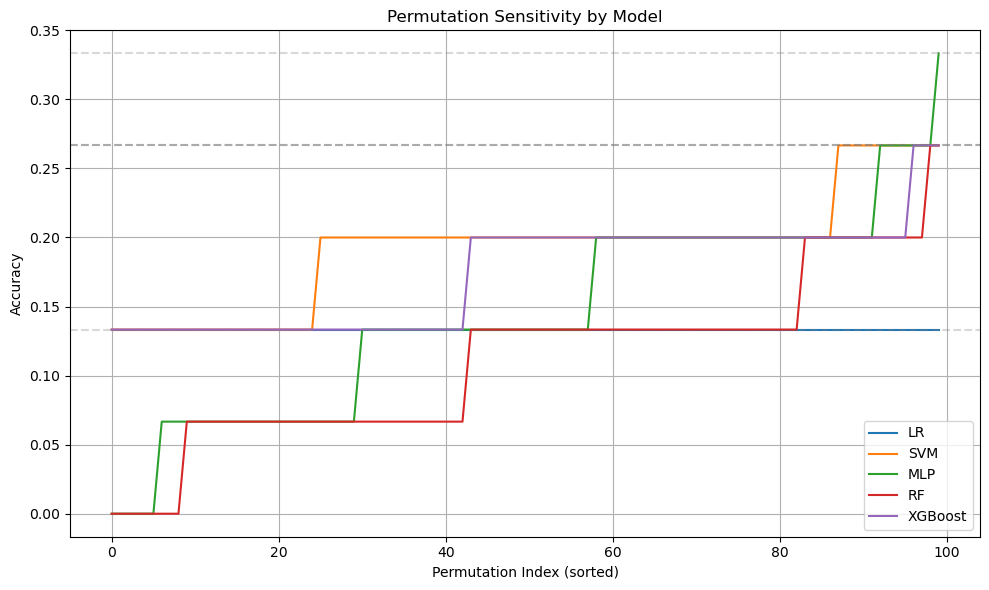

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

data_dir = r"C:\Users\meg57\OneDrive\바탕 화면\은기\진행중\PFAS_transcriptomics_read-across\classification\Final"
file = "Toxcast_rearranged.xlsx"
label_path = os.path.join(data_dir, "label.xlsx")

df_raw = pd.read_excel(os.path.join(data_dir, file), index_col=0).T
label_df = pd.read_excel(label_path, index_col=0)
df_raw["Label"] = label_df.iloc[:, 0].loc[df_raw.index]

X_raw = df_raw.drop(columns=["Label"])
y_raw = df_raw["Label"]
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

original_columns = X_raw.columns.tolist()
feature_name_map = {f"F{str(i+1).zfill(3)}": col for i, col in enumerate(original_columns)}
X_raw.columns = list(feature_name_map.keys())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_dict = {
    "LR": LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
    "SVM": LinearSVC(C=0.5, penalty='l1', dual=False, random_state=42, max_iter=5000),
    "MLP": MLPClassifier(random_state=42, max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                             use_label_encoder=False, eval_metric='logloss', random_state=42)
}

n_perm = 100
model_acc_results = {}
model_acc_detail = {}

for model_name, model in model_dict.items():
    acc_list = []
    acc_detail = []

    for i in range(n_perm):
        X_perm = X_raw.sample(frac=1, axis=1, random_state=i)
        model_copy = clone(model)
        scores = cross_val_score(model_copy, X_perm, y_encoded, cv=cv, scoring='accuracy')
        acc_list.append(scores.mean())
        acc_detail.append((i, scores.mean(), list(X_perm.columns), X_perm.index.tolist()))

    model_acc_results[model_name] = acc_list
    model_acc_detail[model_name] = acc_detail

plt.figure(figsize=(10, 6))
for model_name, accs in model_acc_results.items():
    accs = np.array(accs)
    plt.plot(sorted(accs), label=model_name)
    plt.axhline(np.max(accs), linestyle='--', color='gray', alpha=0.3)
plt.title("Permutation Sensitivity by Model")
plt.xlabel("Permutation Index (sorted)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

max_accuracy_info = {}

for model_name in model_dict.keys():
    accs = np.array(model_acc_results[model_name])
    details = model_acc_detail[model_name]

    max_idx = np.argmax(accs)
    max_perm_id, max_acc, max_feature_order, max_sample_order = details[max_idx]

    X_max_feature_ordered = X_raw[max_feature_order]
    X_max_sample_ordered = X_max_feature_ordered.loc[max_sample_order]

    max_accuracy_info[model_name] = {
        "max_accuracy": max_acc,
        "permutation_id": max_perm_id,
        "feature_order": max_feature_order,
        "sample_order": max_sample_order,
        "X_feature_ordered": X_max_feature_ordered,
        "X_sample_ordered": X_max_sample_ordered
    }

In [2]:
summary_stats = []

for model_name in model_dict.keys():
    accs = np.array(model_acc_results[model_name])
    details = model_acc_detail[model_name]

    # 전체 평균/표준편차
    mean_all = accs.mean()
    std_all = accs.std()

    # 최대 정확도
    max_idx = np.argmax(accs)
    max_acc = accs[max_idx]

    # 해당 permutation의 std 구하기
    perm_id, _, _, _ = details[max_idx]
    X_perm = X_raw.sample(frac=1, axis=1, random_state=perm_id)
    model_copy = clone(model_dict[model_name])
    fold_scores = cross_val_score(model_copy, X_perm, y_encoded, cv=cv, scoring='accuracy')
    max_std = fold_scores.std()

    summary_stats.append({
        "Model": model_name,
        "Max Accuracy": round(max_acc, 4),
        "Max Accuracy Std": round(max_std, 4),
        "Permutation Mean": round(mean_all, 4),
        "Permutation Std": round(std_all, 4)
    })

summary_df = pd.DataFrame(summary_stats)
display(summary_df)

,Model,Max Accuracy,Max Accuracy Std,Permutation Mean,Permutation Std
0,LR,0.1333,0.1633,0.1333,0.0000
1,SVM,0.2667,0.2494,0.1920,0.0403
2,MLP,0.3333,0.2981,0.1433,0.0720
3,RF,0.2667,0.1333,0.1113,0.0604
4,XGBoost,0.2667,0.1333,0.1740,0.0376


In [3]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, cross_val_predict

n_perm = 100
max_features = 266
best_feature_summary = {}
feature_performance_by_model = {}
best_df_dict = {}  # 모델별 best_df 저장용

for model_name, model in model_dict.items():
    print(f"\n🔍 Evaluating model: {model_name}")

    X_full = max_accuracy_info[model_name]["X_feature_ordered"]
    y = y_encoded

    # Feature importance 계산
    model_clone = clone(model)
    model_clone.fit(X_full, y)

    if hasattr(model_clone, "coef_"):
        feat_series = pd.Series(np.mean(np.abs(model_clone.coef_), axis=0), index=X_full.columns)
    elif hasattr(model_clone, "feature_importances_"):
        feat_series = pd.Series(model_clone.feature_importances_, index=X_full.columns)
    else:
        result = permutation_importance(model_clone, X_full, y, scoring='accuracy', n_repeats=100, random_state=42)
        feat_series = pd.Series(result.importances_mean, index=X_full.columns)

    sorted_features = feat_series.sort_values(ascending=False).index.tolist()

    # 탐색 초기화
    best_acc = 0
    best_std = 0
    best_k = 0
    best_feats = []
    best_failed = []
    best_df = None

    feature_counts = []
    mean_scores = []
    std_scores = []

    for k in range(1, min(max_features, len(sorted_features)) + 1):
        selected_feats = sorted_features[:k]
        acc_list = []

        for i in range(n_perm):
            X_perm = X_full[selected_feats].sample(frac=1, axis=1, random_state=i)
            scores = cross_val_score(clone(model), X_perm, y, cv=cv, scoring='accuracy')
            acc_list.append(scores.mean())

        acc_array = np.array(acc_list)
        mean_acc, std_acc = acc_array.mean(), acc_array.std()

        feature_counts.append(k)
        mean_scores.append(mean_acc)
        std_scores.append(std_acc)

        if mean_acc > best_acc:
            best_acc = mean_acc
            best_std = std_acc
            best_k = k
            best_feats = selected_feats

            final_model = clone(model)
            cv_scores = cross_val_score(final_model, X_full[best_feats], y, cv=cv, scoring='accuracy')
            best_std = cv_scores.std()

            final_model.fit(X_full[best_feats], y)
            y_pred = cross_val_predict(final_model, X_full[best_feats], y, cv=cv)
            best_failed = X_full.index[y_pred != y].tolist()

            df_best = X_full[best_feats].copy()
            df_best.columns = [feature_name_map.get(c, c) for c in df_best.columns]
            best_df = df_best

    best_feature_summary[model_name] = {
        "num_features": best_k,
        "feature_names": [feature_name_map.get(f, f) for f in best_feats],
        "cv_mean": round(best_acc, 4),
        "cv_std": round(best_std, 4),
        "failed_samples": best_failed,
        "dataframe": best_df
    }

    best_df_dict[model_name] = best_df

    feature_performance_by_model[model_name] = {
        "feature_counts": feature_counts,
        "mean_scores": mean_scores,
        "std_scores": std_scores
    }

    print(f"⭐ {model_name} - Best #features: {best_k}")
    print("🧬 Important Features:", best_feature_summary[model_name]["feature_names"])
    print(f"📈 Accuracy: {best_acc:.4f} ± {best_std:.4f}")
    print(f"❌ Failed PFAS Samples: {best_failed if best_failed else 'None'}")


🔍 Evaluating model: LR
⭐ LR - Best #features: 13
🧬 Important Features: ['ATG_ERa_TRANS', 'BSK_KF3CT_TIMP2', 'BSK_BE3C_uPA', 'BSK_KF3CT_IL1a', 'ATG_Ets_CIS', 'BSK_BF4T_Keratin818', 'BSK_hDFCGF_TIMP2', 'ATG_NF_kB_CIS', 'ATG_TA_CIS', 'ATG_NRF2_ARE_CIS', 'ATG_TGFb_CIS', 'ATG_PPRE_CIS', 'CCTE_GLTED_hDIO1']
📈 Accuracy: 0.8000 ± 0.1633
❌ Failed PFAS Samples: ['PFAS_3', 'PFAS_4', 'PFAS_13']

🔍 Evaluating model: SVM
⭐ SVM - Best #features: 3
🧬 Important Features: ['BSK_BF4T_Keratin818', 'ATG_NF_kB_CIS', 'CCTE_GLTED_hDIO1']
📈 Accuracy: 0.7333 ± 0.1333
❌ Failed PFAS Samples: ['PFAS_3', 'PFAS_9', 'PFAS_11', 'PFAS_13']

🔍 Evaluating model: MLP
⭐ MLP - Best #features: 45
🧬 Important Features: ['BSK_hDFCGF_PAI1', 'CCTE_Shafer_MEA_dev_network_spike_number', 'ATG_HIF1a_CIS', 'ATG_ERRg_TRANS', 'BSK_SAg_CD40', 'BSK_BT_xIL6', 'BSK_CASM3C_MIG', 'BSK_BE3C_MIG', 'BSK_IMphg_MIP1a', 'BSK_hDFCGF_ICAM1', 'BSK_4H_Eotaxin3', 'CCTE_GLTED_hTBG', 'ATG_VDRE_CIS', 'ATG_CRE_CIS', 'BSK_CASM3C_Thrombomodulin', 'BSK_KF3CT

,Model,Best Feature #,Max Accuracy,Max Accuracy Std,Permutation Mean,Permutation Std
0,LR,13,0.8000,0.1633,0.6130,0.1359
1,SVM,3,0.7333,0.1333,0.3873,0.1183
2,MLP,45,0.2807,0.2108,0.1455,0.0883
3,RF,9,0.4980,0.1633,0.3591,0.0730
4,XGBoost,6,0.8000,0.2667,0.4202,0.1399


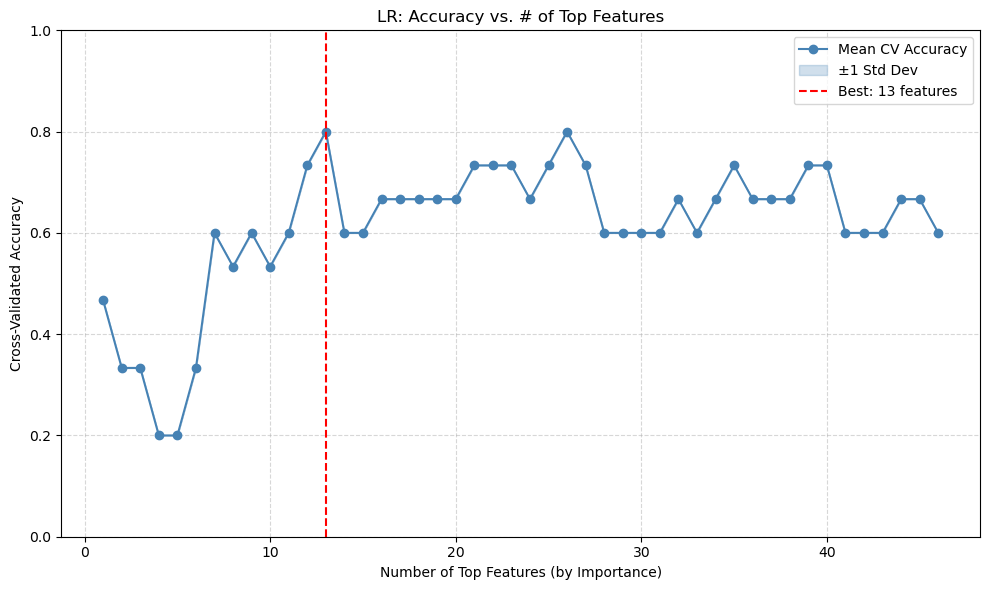

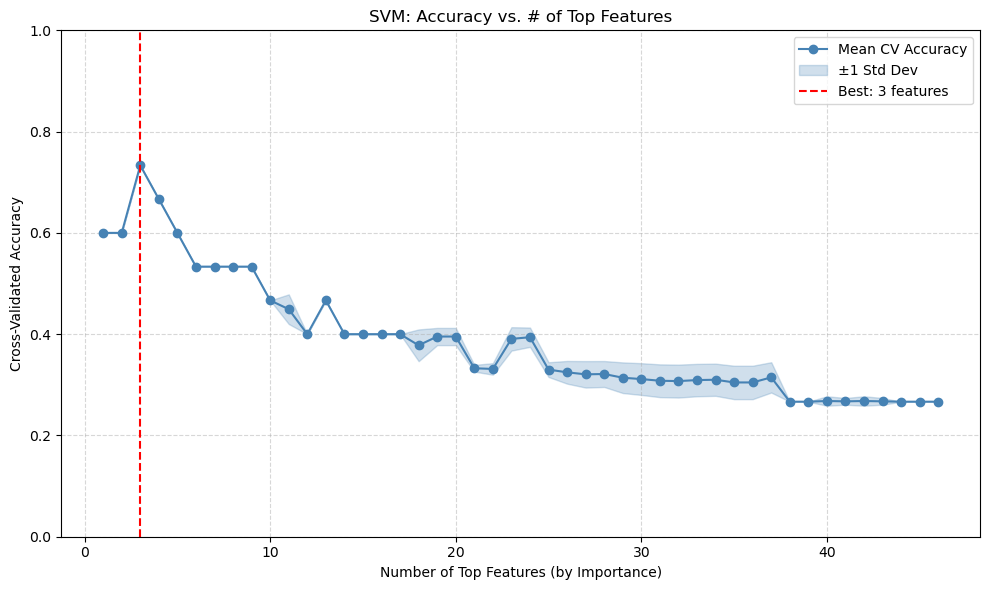

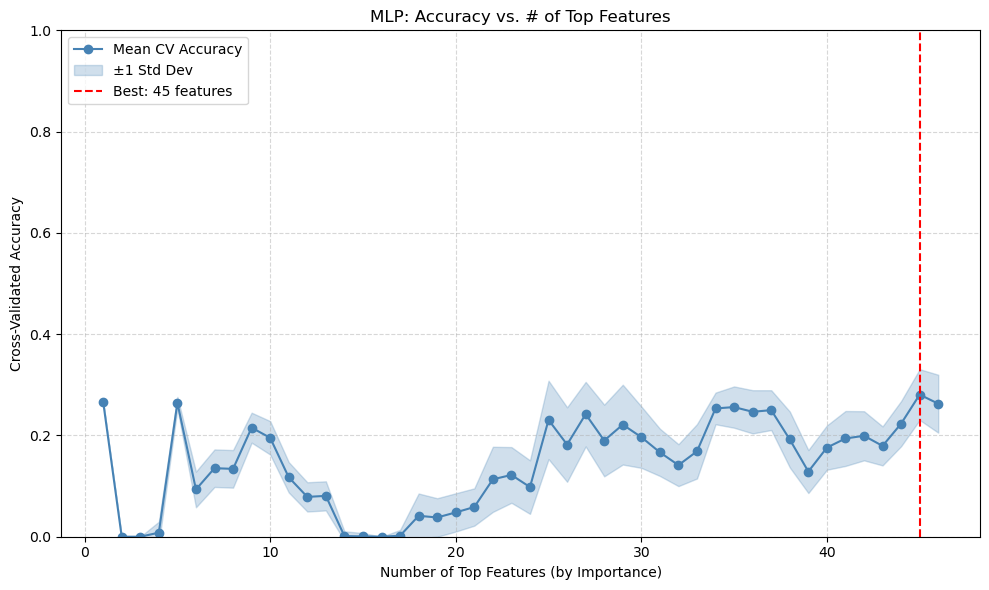

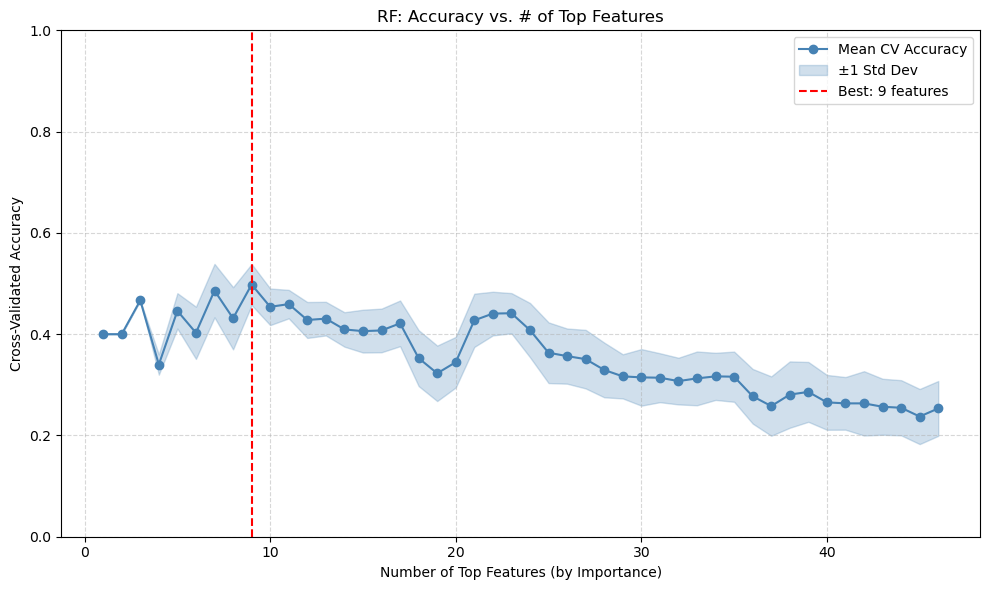

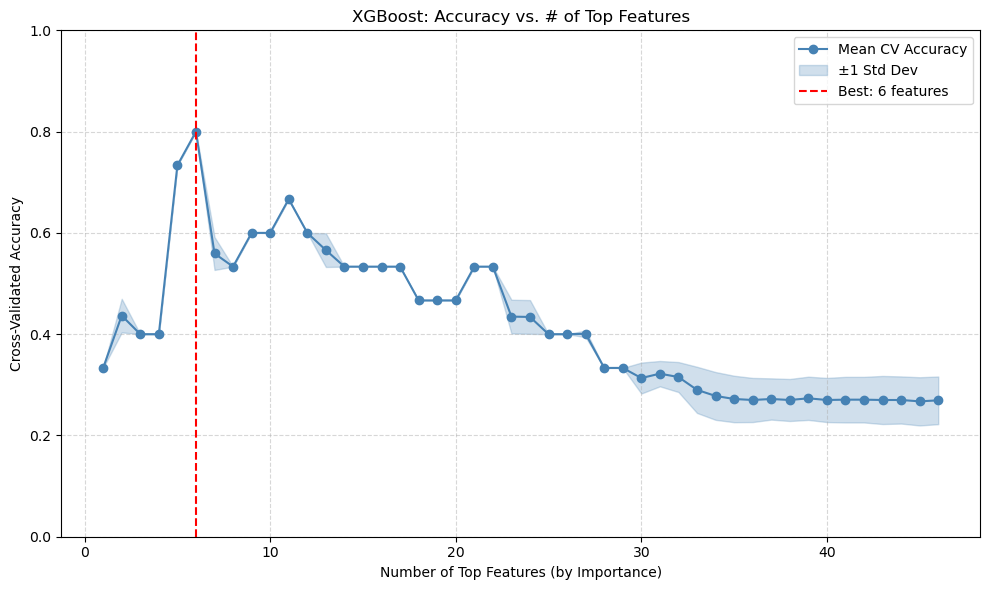

In [4]:
summary_data = []

for model_name in model_dict.keys():
    best_info = best_feature_summary[model_name]
    perf_info = feature_performance_by_model[model_name]

    max_acc = best_info["cv_mean"]
    max_std = best_info["cv_std"]
    best_k = best_info["num_features"]

    perm_mean = np.mean(perf_info["mean_scores"])
    perm_std = np.std(perf_info["mean_scores"])

    summary_data.append({
        "Model": model_name,
        "Best Feature #": best_k,
        "Max Accuracy": round(max_acc, 4),
        "Max Accuracy Std": round(max_std, 4),
        "Permutation Mean": round(perm_mean, 4),
        "Permutation Std": round(perm_std, 4)        
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

for model_name, info in feature_performance_by_model.items():
    feature_counts = info["feature_counts"]
    mean_scores = info["mean_scores"]
    std_scores = info["std_scores"]
    best_k = best_feature_summary[model_name]["num_features"]

    plt.figure(figsize=(10, 6))
    plt.plot(feature_counts, mean_scores, marker='o', label='Mean CV Accuracy', color='steelblue')
    plt.fill_between(feature_counts,
                     np.array(mean_scores) - np.array(std_scores),
                     np.array(mean_scores) + np.array(std_scores),
                     alpha=0.25, color='steelblue', label='±1 Std Dev')
    plt.axvline(best_k, color='red', linestyle='--', label=f'Best: {best_k} features')
    plt.title(f"{model_name}: Accuracy vs. # of Top Features")
    plt.xlabel("Number of Top Features (by Importance)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
output_dir = r"C:\Users\meg57\OneDrive\바탕 화면\은기\진행중\PFAS_transcriptomics_read-across\classification\Final\Toxcast_selected"
os.makedirs(output_dir, exist_ok=True)  # 폴더 없으면 생성

for model_name, df in best_df_dict.items():
    output_path = os.path.join(output_dir, f"best_features_{model_name}.xlsx")
    df.to_excel(output_path)
    print(f"✅ Saved: {output_path}")

✅ Saved: C:\Users\meg57\OneDrive\바탕 화면\은기\진행중\PFAS_transcriptomics_read-across\classification\Final\Toxcast_selected\best_features_LR.xlsx
✅ Saved: C:\Users\meg57\OneDrive\바탕 화면\은기\진행중\PFAS_transcriptomics_read-across\classification\Final\Toxcast_selected\best_features_SVM.xlsx
✅ Saved: C:\Users\meg57\OneDrive\바탕 화면\은기\진행중\PFAS_transcriptomics_read-across\classification\Final\Toxcast_selected\best_features_MLP.xlsx
✅ Saved: C:\Users\meg57\OneDrive\바탕 화면\은기\진행중\PFAS_transcriptomics_read-across\classification\Final\Toxcast_selected\best_features_RF.xlsx
✅ Saved: C:\Users\meg57\OneDrive\바탕 화면\은기\진행중\PFAS_transcriptomics_read-across\classification\Final\Toxcast_selected\best_features_XGBoost.xlsx



📂 Clustermap for: best_features_SVM.xlsx


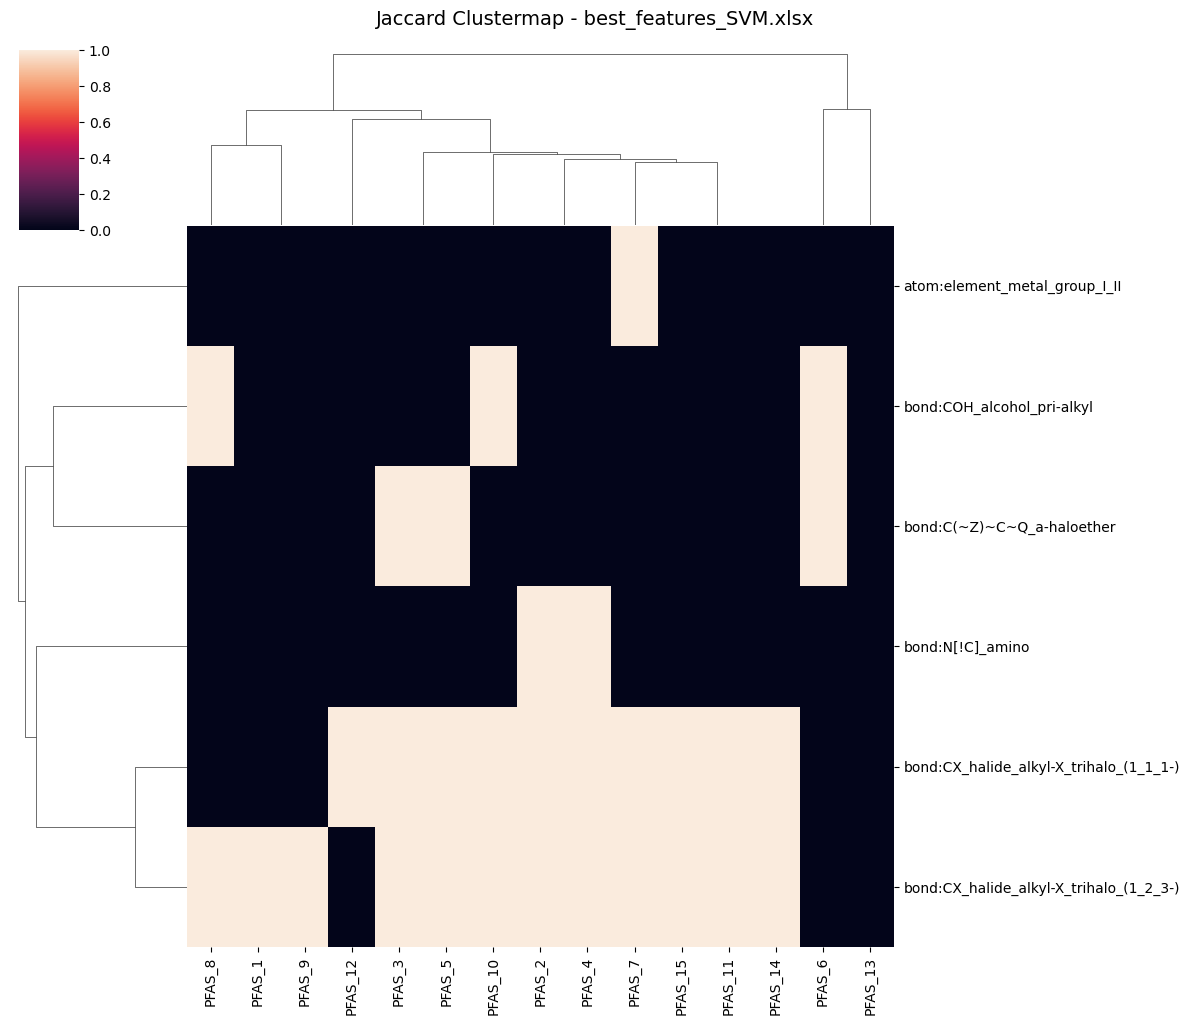

1


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform

def jaccard_clustermap(df, title="Clustermap"):
    features = df.drop(columns=["Label"]) if "Label" in df.columns else df
    features = features.astype(int)
    features_T = features.T  # feature × sample

    row_dist = squareform(pdist(features_T, metric='jaccard'))  # features 간
    col_dist = squareform(pdist(features_T.T, metric='jaccard'))  # samples 간

    linkage_row = sch.linkage(row_dist, method='average')
    linkage_col = sch.linkage(col_dist, method='average')

    sns.clustermap(
        data=features_T,
        row_linkage=linkage_row,
        col_linkage=linkage_col,
        cmap="rocket",
        figsize=(12, 10)
    )
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.show()

import_dir = r"C:\Users\meg57\OneDrive\바탕 화면\은기\진행중\PFAS_transcriptomics_read-across\classification\Final\Toxcast_selected"
excel_files = [f for f in os.listdir(import_dir) if f.endswith("best_features_SVM.xlsx")]

for file in excel_files:
    print(f"\n📂 Clustermap for: {file}")
    file_path = os.path.join(import_dir, file)
    df = pd.read_excel(file_path, index_col=0)
    jaccard_clustermap(df, title=f"Jaccard Clustermap - {file.replace('_best_features_SVM.xlsx','')}")

print("1")